# Proyecto Integrador — Maestría en Inteligencia Artificial Aplicada

## Avance 5. Modelos de Ensamble y Validación Temporal — Plataforma PACS/RIS

---

**Quinto Avance:** En la Fase 4 alcanzamos F1-macro = 1.0 con Decision Tree. Sin embargo, identificamos que este resultado es producto de **circularidad** entre las features y la variable objetivo: ambas se calculan con los mismos datos en el mismo horizonte temporal.

En esta fase corregimos esa limitación con tres mejoras fundamentales:

1. **Separación temporal features ↔ etiqueta:** las features se calculan con los primeros N meses del cliente; la etiqueta se evalúa con datos completos (6+ meses). Esto simula el escenario real de producción.
2. **Features de tendencia temporal:** capturamos la dinámica de uso (creciente, estable, decreciente) en los primeros meses.
3. **Modelos de ensamble** (homogéneos y heterogéneos) evaluados bajo condiciones realistas.

El resultado es un modelo cuyas métricas reflejan el rendimiento esperado en producción, no en laboratorio.

**Equipo 4:**
- Andrés Castillo Nassar — Experto de Dominio (Head of RevOps, Eden)
- Renzo Felipe Chávez Pulgar — Ingeniero de ML
- César Manuel Tirado Peraza — Analista de Datos

## Contenido

1. [Diagnóstico de la Fase 4 y justificación del replanteamiento](#diagnostico)
2. [Configuración del entorno](#config)
3. [Pipeline de datos (Fases 1-2)](#pipeline)
4. [Separación temporal: features por ventana, etiqueta completa](#temporal)
5. [Nuevas features de tendencia temporal](#trend_features)
6. [Construcción de datasets por ventana](#datasets)
7. [Modelos de ensamble homogéneos y heterogéneos](#ensambles)
8. [Tabla comparativa: individuales vs. ensambles por ventana](#comparativa)
9. [Modelo binario Riesgo vs. Saludable](#binario)
10. [Curva de rendimiento vs. horizonte temporal](#curva)
11. [Modelo final: gráficos de diagnóstico](#graficos)
12. [Conclusiones y recomendaciones para deployment](#conclusiones)

<a name="diagnostico"></a>
## 1. Diagnóstico de la Fase 4 y justificación del replanteamiento

### 1.1 La circularidad detectada

En la Fase 4 (§8.2) reconocimos que la variable objetivo `engagement` se construye con la función `clasificar_engagement()`, que usa directamente `ratio_utilizacion`, `meses_facturado`, `tasa_firma` y `total_estudios` — las mismas variables que son features del modelo. Un Decision Tree puede reconstruir exactamente estas reglas con splits en los umbrales (0.3, 0.7, etc.), produciendo F1 = 1.0.

Esto se denomina **target leakage por construcción**: el modelo no predice nada nuevo, solo replica las reglas que definimos. Las métricas de la Fase 4 no representan el rendimiento esperado en producción.

### 1.2 El problema temporal

En producción, cuando un cliente nuevo firma con Eden, el equipo de CS necesita saber en los **primeros 1-2 meses** si ese cliente va a tener problemas de adopción **a los 6 meses**. El modelo de la Fase 4 usa datos de toda la vida del cliente — equivale a predecir el resultado de un partido después de que terminó.

### 1.3 Solución implementada

| Componente | Fase 4 | Fase 5 |
|---|---|---|
| Features | Datos completos (toda la vida) | Datos parciales (primeros N meses) |
| Etiqueta | `clasificar_engagement()` sobre datos completos | Igual — pero ya no es circular |
| Split | Aleatorio estratificado | **Temporal** (train = pasado, test = futuro) |
| Métricas resultantes | F1 = 1.0 (artificial) | F1 realista para producción |

<a name="config"></a>
## 2. Configuración del entorno

In [1]:
# CONFIGURACIÓN DEL ENTORNO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, time
from datetime import timedelta

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_score)
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, PowerTransformer,
                                   LabelEncoder, label_binarize)
from sklearn.feature_selection import (SelectKBest, f_classif, chi2,
                                       mutual_info_classif, VarianceThreshold)
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             cohen_kappa_score, classification_report,
                             confusion_matrix, roc_curve, auc, precision_recall_curve,
                             average_precision_score, roc_auc_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier,
                              BaggingClassifier, AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import skew

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.titlesize': 12})
SEED = 42
np.random.seed(SEED)

print('✅ Entorno configurado')

✅ Entorno configurado


<a name="pipeline"></a>
## 3. Pipeline de datos (Fases 1-2)

Replicamos la carga de los 13 archivos originales. A diferencia de la Fase 4, **no agregamos inmediatamente** — conservamos la granularidad mensual para poder filtrar por ventana temporal.

In [2]:
# CARGA DE DATOS CRUDOS (SIN AGREGAR)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/proyecto integrador (grupo 4)/datos_v1'
except:
    DATA_DIR = 'datos_v1'

archivos = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.xlsx')])
print(f'{len(archivos)} archivos encontrados en {DATA_DIR}')

def buscar(kw):
    for f in archivos:
        if kw.lower() in f.lower(): return os.path.join(DATA_DIR, f)

def cargar_mh(fp):
    xlsx = pd.ExcelFile(fp); frames = []
    for s in xlsx.sheet_names:
        d = pd.read_excel(fp, sheet_name=s)
        d['year'] = s if 'year' not in d.columns else d['year']
        frames.append(d)
    return pd.concat(frames, ignore_index=True)

COL_ING = 'Ingresos USD (Tasa 1 USD =19.3 MXN)'

# Archivos temporales (conservar columna month/mes_anio)
di = pd.read_excel(buscar('Ingresos'))
ds = cargar_mh(buscar('sucursal'))
dm = cargar_mh(buscar('modalidad'))
dat = pd.read_excel(buscar('rax'))
dar = pd.read_excel(buscar('AI Rep'))
du = cargar_mh(buscar('usuarios'))
de_ = cargar_mh(buscar('Env'))
dp = pd.read_excel(buscar('PACS'))
dr = pd.read_excel(buscar('RIS'))

# Archivos estáticos
df_f = pd.read_excel(buscar('facturaci'))
df_inst = pd.read_excel(buscar('nstalaci'))
dpt = pd.read_excel(buscar('potenciales'))

# ─── Normalizar fechas en archivos temporales ───
di['month'] = pd.to_datetime(di['ingresos_month'], errors='coerce')
ds['month'] = pd.to_datetime(ds['month'], errors='coerce')
dm['month'] = pd.to_datetime(dm['month'], errors='coerce')
du['month'] = pd.to_datetime(du['month'], errors='coerce')
de_['month'] = pd.to_datetime(de_['month'], errors='coerce')
dp['month'] = pd.to_datetime(dp['mes_anio'], errors='coerce')
dr['month'] = pd.to_datetime(dr['mes_anio'], errors='coerce')
dar['month'] = pd.to_datetime(dar['month'], errors='coerce')

# AI Tórax tiene year y month separados
dat['month'] = pd.to_datetime(
    dat['year'].astype(str) + '-' + dat['month'].astype(str).str.zfill(2) + '-01',
    errors='coerce')

# ─── Normalizar nombres de org en archivos temporales ───
ds.rename(columns={'organization': 'org'}, inplace=True)
dm.rename(columns={'organization': 'org'}, inplace=True)
di.rename(columns={'name': 'org'}, inplace=True)
du.rename(columns={'organization_name': 'org'}, inplace=True)
de_.rename(columns={'organization_name': 'org'}, inplace=True)
dp.rename(columns={'organization': 'org'}, inplace=True)
dr.rename(columns={'name': 'org'}, inplace=True)
dar.rename(columns={'organization': 'org'}, inplace=True)
co = dat.columns[0]
dat.rename(columns={co: 'org'}, inplace=True)

# ─── Archivos estáticos ───
ci = df_inst.columns
df_inst = df_inst.rename(columns={ci[0]: 'fecha_instalacion', ci[1]: 'org'})
df_inst['fecha_instalacion'] = pd.to_datetime(df_inst['fecha_instalacion'], errors='coerce')
install_dates = df_inst.dropna(subset=['fecha_instalacion']).groupby('org')['fecha_instalacion'].min().reset_index()

df_f = df_f.rename(columns={'name': 'org', 'invoice_start_date': 'fecha_facturacion'})
df_f['fecha_facturacion'] = pd.to_datetime(df_f['fecha_facturacion'], errors='coerce')
fact_dates = df_f.dropna(subset=['fecha_facturacion']).groupby('org')['fecha_facturacion'].min().reset_index()

potencial = dpt[['Cuenta', 'Potencial Mes (contrato)', 'País']].dropna(
    subset=['Potencial Mes (contrato)']
).rename(columns={
    'Cuenta': 'org', 'Potencial Mes (contrato)': 'potencial_mensual', 'País': 'pais'
})

# Producto principal por org
pp = di.groupby('org')[COL_ING].sum().reset_index()
pp_tipo = di.drop_duplicates('org')[['org', 'product_type']]

print(f'\n  Orgs en Ingresos:       {di["org"].nunique():,}')
print(f'  Orgs con instalación:   {install_dates.shape[0]:,}')
print(f'  Rango temporal:         {di["month"].min():%Y-%m} → {di["month"].max():%Y-%m}')
print('\n✅ Datos crudos cargados (granularidad mensual conservada)')

Mounted at /content/drive
13 archivos encontrados en /content/drive/MyDrive/proyecto integrador (grupo 4)/datos_v1

  Orgs en Ingresos:       1,476
  Orgs con instalación:   423
  Rango temporal:         2024-01 → 2026-01

✅ Datos crudos cargados (granularidad mensual conservada)


<a name="temporal"></a>
## 4. Separación temporal: features por ventana, etiqueta completa

### 4.1 Concepto

Para cada organización:
- **Features (X):** se calculan con datos de los primeros N meses desde su fecha de instalación
- **Etiqueta (y):** se calcula con `clasificar_engagement()` usando datos de **toda** su vida

Esto rompe la circularidad: `ratio_utilizacion_2m ≠ ratio_utilizacion_completo`.

### 4.2 Implementación

In [3]:
# ═══════════════════════════════════════════════════════
# FUNCIÓN CENTRAL: construir dataset con ventana temporal
# ═══════════════════════════════════════════════════════

FECHA_REF = pd.Timestamp('2026-01-31')  # Último dato disponible

def construir_dataset_ventana(meses_ventana, meses_min_etiqueta=6):
    """
    Construye un dataset donde:
    - Features se calculan con los primeros `meses_ventana` meses desde instalación
    - Etiqueta se calcula con TODOS los datos disponibles
    - Solo incluye orgs con al menos `meses_min_etiqueta` meses de vida

    Returns: DataFrame con features de ventana + etiqueta completa
    """

    # ─── Paso 1: Filtrar orgs elegibles ───
    orgs = install_dates.copy()
    orgs['vida_meses'] = ((FECHA_REF - orgs['fecha_instalacion']).dt.days / 30.44).round(1)
    orgs = orgs[orgs['vida_meses'] >= meses_min_etiqueta].copy()

    # Calcular fecha de corte por org
    orgs['fecha_corte'] = orgs['fecha_instalacion'] + pd.DateOffset(months=meses_ventana)
    org_set = set(orgs['org'])

    # ─── Paso 2: Funciones de agregación con filtro temporal ───
    def agg_filtrado(df_raw, org_col, month_col, agg_dict, orgs_df):
        """Agrega datos filtrando por ventana temporal de cada org."""
        df = df_raw.copy()
        df = df.rename(columns={org_col: 'org', month_col: 'month_dt'}) if org_col != 'org' else df.copy()
        if month_col != 'month_dt' and 'month_dt' not in df.columns:
            df = df.rename(columns={month_col: 'month_dt'}) if month_col in df.columns else df
            if 'month' in df.columns and 'month_dt' not in df.columns:
                df = df.rename(columns={'month': 'month_dt'})

        # Asegurar columna month_dt existe
        if 'month_dt' not in df.columns:
            if 'month' in df.columns:
                df['month_dt'] = df['month']

        df = df[df['org'].isin(org_set)].copy()
        df = df.merge(orgs_df[['org', 'fecha_instalacion', 'fecha_corte']], on='org', how='inner')
        df = df[(df['month_dt'] >= df['fecha_instalacion']) &
                (df['month_dt'] < df['fecha_corte'])]
        if len(df) == 0:
            return pd.DataFrame(columns=['org'] + list(agg_dict.keys()))
        result = df.groupby('org').agg(**agg_dict).reset_index()
        return result

    def agg_completo(df_raw, org_col, agg_dict):
        """Agrega datos SIN filtro temporal (para etiqueta)."""
        df = df_raw.copy()
        if org_col != 'org':
            df = df.rename(columns={org_col: 'org'})
        df = df[df['org'].isin(org_set)]
        if len(df) == 0:
            return pd.DataFrame(columns=['org'] + list(agg_dict.keys()))
        return df.groupby('org').agg(**agg_dict).reset_index()

    # ─── Paso 3: Agregar datos CON ventana (features) ───
    a1_w = agg_filtrado(di, 'org', 'month', {
        'total_ingresos': (COL_ING, 'sum'),
        'promedio_ingresos': (COL_ING, 'mean'),
        'meses_facturado': (COL_ING, 'count')
    }, orgs)

    a2_w = agg_filtrado(ds, 'org', 'month', {
        'total_estudios': ('study_count', 'sum'),
        'num_sucursales': ('facility', 'nunique')
    }, orgs)

    a3_w = agg_filtrado(du, 'org', 'month', {
        'total_usuarios': ('active_doctors_count', 'sum'),
        'prom_usuarios': ('active_doctors_count', 'mean')
    }, orgs)

    a4_w = agg_filtrado(de_, 'org', 'month', {
        'envios_email': ('studies_sent_via_email', 'sum'),
        'envios_sms': ('studies_sent_via_sms', 'sum')
    }, orgs)

    a5_w = agg_filtrado(dp, 'org', 'month', {
        'firmados': ('signed', 'sum'),
        'entregados': ('delivered', 'sum'),
        'total_pacs': ('total', 'sum')
    }, orgs)

    a6_w = agg_filtrado(dm, 'org', 'month', {
        'num_modalidades': ('modalities', 'nunique'),
        'estudios_mod': ('study_count', 'sum')
    }, orgs)

    # AI dentro de ventana
    aat_w = agg_filtrado(dat, 'org', 'month', {
        'estudios_ai_torax': ('Estudios con IA', 'sum')
    }, orgs)
    aar_w = agg_filtrado(dar, 'org', 'month', {
        'estudios_ai_report': ('study_count', 'sum')
    }, orgs)

    # ─── Paso 4: Agregar datos SIN ventana (para etiqueta) ───
    a1_c = agg_completo(di, 'org', {
        'total_ingresos_c': (COL_ING, 'sum'),
        'meses_facturado_c': (COL_ING, 'count')
    })
    a2_c = agg_completo(ds, 'org', {
        'total_estudios_c': ('study_count', 'sum'),
    })
    a5_c = agg_completo(dp, 'org', {
        'firmados_c': ('signed', 'sum'),
        'total_pacs_c': ('total', 'sum')
    })

    # ─── Paso 5: Merge features (ventana) ───
    feat = orgs[['org', 'fecha_instalacion', 'vida_meses']].copy()
    for a in [a1_w, a2_w, a3_w, a4_w, a5_w, a6_w, aat_w, aar_w, potencial, fact_dates]:
        feat = feat.merge(a, on='org', how='left')

    # Merge producto
    feat = feat.merge(pp_tipo, on='org', how='left')

    # Imputar NaN con 0 para features de actividad
    act_cols = ['total_ingresos', 'promedio_ingresos', 'meses_facturado', 'total_estudios',
                'num_sucursales', 'total_usuarios', 'prom_usuarios', 'envios_email', 'envios_sms',
                'firmados', 'entregados', 'total_pacs', 'num_modalidades', 'estudios_mod',
                'estudios_ai_torax', 'estudios_ai_report']
    for c in act_cols:
        if c in feat.columns:
            feat[c] = feat[c].fillna(0)
    feat['potencial_mensual'] = feat['potencial_mensual'].fillna(feat['potencial_mensual'].median())
    feat['pais'] = feat['pais'].fillna('Desconocido')
    feat['product_type'] = feat['product_type'].fillna('Desconocido')

    # ─── Paso 6: Calcular ratios derivados (sobre datos de ventana) ───
    feat['ratio_utilizacion'] = np.where(
        (feat['potencial_mensual'] > 0) & (feat['meses_facturado'] > 0),
        feat['total_estudios'] / (feat['potencial_mensual'] * feat['meses_facturado']), 0)
    feat['ingreso_por_estudio'] = np.where(
        feat['total_estudios'] > 0, feat['total_ingresos'] / feat['total_estudios'], 0)
    feat['tasa_firma'] = np.where(
        feat['total_pacs'] > 0, feat['firmados'] / feat['total_pacs'], 0)
    feat['tasa_entrega'] = np.where(
        feat['total_pacs'] > 0, feat['entregados'] / feat['total_pacs'], 0)
    feat['estudios_por_sucursal'] = np.where(
        feat['num_sucursales'] > 0, feat['total_estudios'] / feat['num_sucursales'], 0)
    feat['total_envios'] = feat['envios_email'] + feat['envios_sms']
    feat['ratio_envio_total'] = np.where(
        feat['total_estudios'] > 0, feat['total_envios'] / feat['total_estudios'], 0)

    # Winsorizar
    for c in ['ratio_utilizacion', 'ingreso_por_estudio', 'total_ingresos',
              'total_estudios', 'total_usuarios']:
        if c in feat.columns and feat[c].nunique() > 1:
            feat[c] = feat[c].clip(upper=feat[c].quantile(.99))

    # Flags
    feat['usa_ai_torax'] = (feat['estudios_ai_torax'] > 0).astype(int)
    feat['usa_ai_report'] = (feat['estudios_ai_report'] > 0).astype(int)
    feat['usa_alguna_ai'] = ((feat['usa_ai_torax'] + feat['usa_ai_report']) > 0).astype(int)
    feat['usa_email'] = (feat['envios_email'] > 0).astype(int)
    feat['usa_sms'] = (feat['envios_sms'] > 0).astype(int)
    feat['es_multi_sucursal'] = (feat['num_sucursales'] > 1).astype(int)
    feat['es_multi_modalidad'] = (feat['num_modalidades'] > 2).astype(int)

    # Temporales estáticas
    feat['fecha_facturacion'] = pd.to_datetime(feat['fecha_facturacion'], errors='coerce')
    feat['dias_onboarding'] = (feat['fecha_facturacion'] - feat['fecha_instalacion']).dt.days
    feat['dias_onboarding'] = feat['dias_onboarding'].fillna(feat['dias_onboarding'].median()).clip(lower=0)

    # ─── Paso 7: Calcular etiqueta con datos COMPLETOS ───
    label_df = orgs[['org']].copy()
    for a in [a1_c, a2_c, a5_c]:
        label_df = label_df.merge(a, on='org', how='left')
    for c in label_df.columns:
        if c != 'org':
            label_df[c] = label_df[c].fillna(0)

    # Potencial para etiqueta
    label_df = label_df.merge(potencial[['org', 'potencial_mensual']], on='org', how='left')
    label_df['potencial_mensual'] = label_df['potencial_mensual'].fillna(
        label_df['potencial_mensual'].median())

    # Ratios completos para etiqueta
    label_df['ratio_utilizacion_c'] = np.where(
        (label_df['potencial_mensual'] > 0) & (label_df['meses_facturado_c'] > 0),
        label_df['total_estudios_c'] / (label_df['potencial_mensual'] * label_df['meses_facturado_c']), 0)
    label_df['tasa_firma_c'] = np.where(
        label_df['total_pacs_c'] > 0, label_df['firmados_c'] / label_df['total_pacs_c'], 0)

    def clasificar_engagement(row):
        r = row['ratio_utilizacion_c']
        m = row['meses_facturado_c']
        f = row['tasa_firma_c']
        e = row['total_estudios_c']
        if e == 0 or m <= 1: return 'Sin Engagement'
        elif r < 0.3 and f < 0.3: return 'Bajo'
        elif r < 0.7 or f < 0.5: return 'Parcial'
        else: return 'Adecuado'

    label_df['engagement'] = label_df.apply(clasificar_engagement, axis=1)
    em = {'Sin Engagement': 0, 'Bajo': 1, 'Parcial': 2, 'Adecuado': 3}
    label_df['engagement_ord'] = label_df['engagement'].map(em)

    # ─── Paso 8: Unir features (ventana) + etiqueta (completa) ───
    result = feat.merge(label_df[['org', 'engagement', 'engagement_ord']], on='org', how='inner')

    print(f'  Ventana: {meses_ventana} meses | Orgs: {len(result)} | '
          f'Distribución: {dict(result["engagement"].value_counts())}')

    return result


# ─── Construir todos los datasets ───
print('═' * 70)
print('CONSTRUCCIÓN DE DATASETS TEMPORALES')
print('═' * 70)

datasets = {}
for m in [1, 2, 3, 6]:
    datasets[m] = construir_dataset_ventana(m, meses_min_etiqueta=6)

# También el dataset "completo" de Fase 4 para referencia
datasets['completo'] = construir_dataset_ventana(meses_ventana=99, meses_min_etiqueta=6)

print('\n✅ Datasets temporales construidos')

══════════════════════════════════════════════════════════════════════
CONSTRUCCIÓN DE DATASETS TEMPORALES
══════════════════════════════════════════════════════════════════════
  Ventana: 1 meses | Orgs: 239 | Distribución: {'Parcial': np.int64(146), 'Bajo': np.int64(63), 'Adecuado': np.int64(16), 'Sin Engagement': np.int64(14)}
  Ventana: 2 meses | Orgs: 239 | Distribución: {'Parcial': np.int64(146), 'Bajo': np.int64(63), 'Adecuado': np.int64(16), 'Sin Engagement': np.int64(14)}
  Ventana: 3 meses | Orgs: 239 | Distribución: {'Parcial': np.int64(146), 'Bajo': np.int64(63), 'Adecuado': np.int64(16), 'Sin Engagement': np.int64(14)}
  Ventana: 6 meses | Orgs: 239 | Distribución: {'Parcial': np.int64(146), 'Bajo': np.int64(63), 'Adecuado': np.int64(16), 'Sin Engagement': np.int64(14)}
  Ventana: 99 meses | Orgs: 239 | Distribución: {'Parcial': np.int64(146), 'Bajo': np.int64(63), 'Adecuado': np.int64(16), 'Sin Engagement': np.int64(14)}

✅ Datasets temporales construidos


<a name="trend_features"></a>
## 5. Nuevas features de tendencia temporal

Las features del Avance 2 capturan **totales** (cuántos estudios, cuántos firmados). Las features temporales capturan la **dinámica**: ¿el uso crece, se mantiene, o decae?

In [4]:
# ═══════════════════════════════════════════════════════
# FEATURES DE TENDENCIA TEMPORAL
# ═══════════════════════════════════════════════════════

def agregar_features_temporales(dataset_df, meses_ventana):
    """
    Agrega features de tendencia usando datos mensuales dentro de la ventana.
    """
    df = dataset_df.copy()
    org_set = set(df['org'])
    orgs_info = df[['org', 'fecha_instalacion']].copy()
    orgs_info['fecha_corte'] = orgs_info['fecha_instalacion'] + pd.DateOffset(months=meses_ventana)

    # Obtener series mensuales de estudios por org dentro de la ventana
    ds_temp = ds[ds['org'].isin(org_set)].merge(orgs_info, on='org')
    ds_temp = ds_temp[(ds_temp['month'] >= ds_temp['fecha_instalacion']) &
                      (ds_temp['month'] < ds_temp['fecha_corte'])]
    monthly_studies = ds_temp.groupby(['org', 'month'])['study_count'].sum().reset_index()

    # Series de ingresos mensuales
    di_temp = di[di['org'].isin(org_set)].merge(orgs_info, on='org')
    di_temp = di_temp[(di_temp['month'] >= di_temp['fecha_instalacion']) &
                      (di_temp['month'] < di_temp['fecha_corte'])]
    monthly_revenue = di_temp.groupby(['org', 'month'])[COL_ING].sum().reset_index()

    # ─── Calcular features por org ───
    trend_data = []

    for org in org_set:
        row = {'org': org}
        ms = monthly_studies[monthly_studies['org'] == org].sort_values('month')
        mr = monthly_revenue[monthly_revenue['org'] == org].sort_values('month')
        studies_vals = ms['study_count'].values if len(ms) > 0 else np.array([0])
        n_months_active = len(studies_vals)

        # 1. Slope de estudios (tendencia)
        if n_months_active >= 2:
            x = np.arange(n_months_active)
            slope = np.polyfit(x, studies_vals, 1)[0]
            row['slope_estudios'] = slope
        else:
            row['slope_estudios'] = 0

        # 2. Aceleración: último mes vs primer mes
        if n_months_active >= 2 and studies_vals[0] > 0:
            row['aceleracion'] = studies_vals[-1] / studies_vals[0]
        elif n_months_active >= 2:
            row['aceleracion'] = float(studies_vals[-1] > 0)
        else:
            row['aceleracion'] = 1.0
        row['aceleracion'] = min(row['aceleracion'], 10)  # Cap outliers

        # 3. Meses activos / meses en ventana
        meses_con_actividad = (studies_vals > 0).sum()
        row['ratio_meses_activos'] = meses_con_actividad / max(meses_ventana, 1)

        # 4. Concentración de actividad
        total = studies_vals.sum()
        if total > 0 and n_months_active > 0:
            row['concentracion'] = studies_vals.max() / total
        else:
            row['concentracion'] = 1.0

        # 5. Coeficiente de variación (estabilidad de uso)
        if n_months_active >= 2 and studies_vals.mean() > 0:
            row['cv_estudios'] = studies_vals.std() / studies_vals.mean()
        else:
            row['cv_estudios'] = 0

        # 6. Velocidad de activación (meses hasta primer ingreso)
        if len(mr) > 0:
            org_install = orgs_info[orgs_info['org'] == org]['fecha_instalacion'].iloc[0]
            primer_ingreso = mr['month'].min()
            row['meses_hasta_ingreso'] = max(0, (primer_ingreso - org_install).days / 30.44)
        else:
            row['meses_hasta_ingreso'] = meses_ventana  # No facturó en la ventana

        trend_data.append(row)

    trend_df = pd.DataFrame(trend_data)

    # Merge con dataset
    df = df.merge(trend_df, on='org', how='left')

    # Imputar NaN
    trend_cols = ['slope_estudios', 'aceleracion', 'ratio_meses_activos',
                  'concentracion', 'cv_estudios', 'meses_hasta_ingreso']
    for c in trend_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0)

    return df, trend_cols


# ─── Aplicar a todos los datasets ───
print('═' * 70)
print('FEATURES DE TENDENCIA TEMPORAL')
print('═' * 70)

trend_cols_all = []
for m in datasets:
    mv = m if isinstance(m, int) else 99
    datasets[m], tc = agregar_features_temporales(datasets[m], mv)
    trend_cols_all = tc
    n = len(datasets[m])
    print(f'  Ventana {str(m):>9s}: {n:>4} orgs, {len(tc)} features temporales agregadas')

print(f'\n  Features temporales: {trend_cols_all}')
print('\n✅ Features de tendencia temporal agregadas')

══════════════════════════════════════════════════════════════════════
FEATURES DE TENDENCIA TEMPORAL
══════════════════════════════════════════════════════════════════════
  Ventana         1:  239 orgs, 6 features temporales agregadas
  Ventana         2:  239 orgs, 6 features temporales agregadas
  Ventana         3:  239 orgs, 6 features temporales agregadas
  Ventana         6:  239 orgs, 6 features temporales agregadas
  Ventana  completo:  239 orgs, 6 features temporales agregadas

  Features temporales: ['slope_estudios', 'aceleracion', 'ratio_meses_activos', 'concentracion', 'cv_estudios', 'meses_hasta_ingreso']

✅ Features de tendencia temporal agregadas


<a name="datasets"></a>
## 6. Construcción de datasets por ventana

### 6.1 Preparación de features y split temporal

In [5]:
# ═══════════════════════════════════════════════════════
# PREPARACIÓN DE FEATURES Y SPLIT TEMPORAL
# ═══════════════════════════════════════════════════════

def preparar_xy(df_dataset, test_ratio=0.25):
    """
    Prepara X, y con split TEMPORAL (no aleatorio).
    Train = orgs más antiguas, Test = orgs más recientes.
    """
    df = df_dataset.copy()

    # Features numéricas
    exclude = ['org', 'engagement', 'engagement_ord', 'fecha_instalacion',
               'fecha_facturacion', 'fecha_corte', 'vida_meses', 'pais', 'product_type']
    num_features = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64', 'int32', 'float32']]

    # Encoding categóricas
    if 'product_type' in df.columns:
        dummies_pt = pd.get_dummies(df['product_type'], prefix='prod', drop_first=False)
        df = pd.concat([df, dummies_pt], axis=1)
        num_features += list(dummies_pt.columns)
    if 'pais' in df.columns:
        top_paises = df['pais'].value_counts()
        df['pais_agr'] = df['pais'].where(df['pais'].isin(top_paises[top_paises >= 5].index), 'Otro')
        dummies_pa = pd.get_dummies(df['pais_agr'], prefix='pais', drop_first=False)
        df = pd.concat([df, dummies_pa], axis=1)
        num_features += list(dummies_pa.columns)

    # Limpiar features
    num_features = [f for f in dict.fromkeys(num_features) if f in df.columns]

    X = df[num_features].fillna(0)
    y = df['engagement_ord']

    # ─── Split TEMPORAL ───
    # Ordenar por fecha de instalación
    df_sorted = df.sort_values('fecha_instalacion').reset_index(drop=True)
    X = df_sorted[num_features].fillna(0)
    y = df_sorted['engagement_ord']

    split_idx = int(len(df_sorted) * (1 - test_ratio))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Escalar
    scaler = StandardScaler()
    X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=num_features, index=X_train.index)
    X_test_s = pd.DataFrame(scaler.transform(X_test), columns=num_features, index=X_test.index)

    return X_train, X_test, X_train_s, X_test_s, y_train, y_test, num_features


# ─── Preparar todos los datasets ───
print('═' * 70)
print('SPLIT TEMPORAL DE DATASETS')
print('═' * 70)

prepared = {}
for m in datasets:
    if len(datasets[m]) < 20:
        print(f'  Ventana {str(m):>9s}: OMITIDA (solo {len(datasets[m])} orgs)')
        continue
    Xtr, Xte, Xtr_s, Xte_s, ytr, yte, feats = preparar_xy(datasets[m])
    prepared[m] = {
        'X_train': Xtr, 'X_test': Xte,
        'X_train_s': Xtr_s, 'X_test_s': Xte_s,
        'y_train': ytr, 'y_test': yte,
        'features': feats
    }
    print(f'  Ventana {str(m):>9s}: Train={len(Xtr):>4} | Test={len(Xte):>4} | '
          f'Features={len(feats):>3} | Clases train: {dict(ytr.value_counts().sort_index())}')

print('\n✅ Datasets preparados con split temporal')

══════════════════════════════════════════════════════════════════════
SPLIT TEMPORAL DE DATASETS
══════════════════════════════════════════════════════════════════════
  Ventana         1: Train= 179 | Test=  60 | Features= 50 | Clases train: {0: np.int64(11), 1: np.int64(44), 2: np.int64(113), 3: np.int64(11)}
  Ventana         2: Train= 179 | Test=  60 | Features= 50 | Clases train: {0: np.int64(11), 1: np.int64(44), 2: np.int64(113), 3: np.int64(11)}
  Ventana         3: Train= 179 | Test=  60 | Features= 50 | Clases train: {0: np.int64(11), 1: np.int64(44), 2: np.int64(113), 3: np.int64(11)}
  Ventana         6: Train= 179 | Test=  60 | Features= 50 | Clases train: {0: np.int64(11), 1: np.int64(44), 2: np.int64(113), 3: np.int64(11)}
  Ventana  completo: Train= 179 | Test=  60 | Features= 50 | Clases train: {0: np.int64(11), 1: np.int64(44), 2: np.int64(113), 3: np.int64(11)}

✅ Datasets preparados con split temporal


<a name="ensambles"></a>
## 7. Modelos de ensamble homogéneos y heterogéneos

### 7.1 Diseño experimental

Evaluamos tres familias de ensambles:

| Tipo | Estrategia | Modelos base |
|---|---|---|
| **Homogéneo** | Bagging sobre Decision Tree | DT con bootstrap |
| **Homogéneo** | AdaBoost sobre Decision Tree | DT con boosting secuencial |
| **Heterogéneo** | Voting (soft) | DT + XGBoost + LightGBM + LogReg |
| **Heterogéneo** | Stacking | DT + XGBoost + LightGBM → meta-learner LogReg |

Además, re-evaluamos los 4 mejores modelos individuales de la Fase 4 para tener la comparación directa bajo condiciones temporales.

In [6]:
# ═══════════════════════════════════════════════════════
# FUNCIÓN DE EVALUACIÓN (extendida de Fase 4)
# ═══════════════════════════════════════════════════════

def evaluar_modelo(nombre, modelo, Xtr, Xte, ytr, yte, escalar=False):
    """Entrena y evalúa un modelo. Si escalar=True, usa X escalado."""
    t0 = time.time()
    modelo.fit(Xtr, ytr)
    t_train = time.time() - t0

    yp_tr = modelo.predict(Xtr)
    yp_te = modelo.predict(Xte)

    return {
        'Modelo': nombre,
        'F1m_train': round(f1_score(ytr, yp_tr, average='macro', zero_division=0), 4),
        'F1m_test':  round(f1_score(yte, yp_te, average='macro', zero_division=0), 4),
        'Acc_test':  round(accuracy_score(yte, yp_te), 4),
        'BalAcc':    round(balanced_accuracy_score(yte, yp_te), 4),
        'Kappa':     round(cohen_kappa_score(yte, yp_te), 4),
        'Gap':       round(abs(f1_score(ytr, yp_tr, average='macro', zero_division=0) -
                        f1_score(yte, yp_te, average='macro', zero_division=0)), 4),
        'Tiempo_s':  round(t_train, 3),
        'modelo_obj': modelo,
        'y_pred':    yp_te,
        'y_pred_tr': yp_tr
    }

print('✅ Función de evaluación definida')

✅ Función de evaluación definida


In [7]:
# ═══════════════════════════════════════════════════════
# ENTRENAMIENTO: INDIVIDUALES + ENSAMBLES POR VENTANA
# ═══════════════════════════════════════════════════════

all_results = {}  # {ventana: [resultados]}

# Ventana principal para ensambles (usamos la que tenga más datos razonables)
for m_key in prepared:
    d = prepared[m_key]
    Xtr, Xte = d['X_train'], d['X_test']
    Xtr_s, Xte_s = d['X_train_s'], d['X_test_s']
    ytr, yte = d['y_train'], d['y_test']

    print(f'\n{"═" * 70}')
    print(f'VENTANA: {m_key} {"meses" if isinstance(m_key, int) else "(referencia)"}')
    print(f'{"═" * 70}')
    print(f'  Train: {len(Xtr)} | Test: {len(Xte)}')

    resultados = []

    # ─── A) Modelos individuales (mejores de Fase 4) ───
    print('\n  ── Modelos individuales ──')

    modelos_ind = {
        'Decision Tree': DecisionTreeClassifier(
            class_weight='balanced', random_state=SEED),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            random_state=SEED, eval_metric='mlogloss', verbosity=0),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            random_state=SEED, class_weight='balanced', verbose=-1),
        'LogReg (baseline)': LogisticRegression(
            max_iter=2000, class_weight='balanced', random_state=SEED),
    }

    for name, mod in modelos_ind.items():
        use_scaled = name in ['LogReg (baseline)']
        X_tr = Xtr_s if use_scaled else Xtr
        X_te = Xte_s if use_scaled else Xte
        res = evaluar_modelo(name, mod, X_tr, X_te, ytr, yte)
        res['Tipo'] = 'Individual'
        res['Ventana'] = m_key
        resultados.append(res)
        print(f"    {name:<25} F1m={res['F1m_test']:.4f}  gap={res['Gap']:.4f}  t={res['Tiempo_s']}s")

    # ─── B) Ensambles homogéneos ───
    print('\n  ── Ensambles homogéneos ──')

    # Bagging sobre Decision Tree
    bag_dt = BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
        n_estimators=50, max_samples=0.8, max_features=0.8,
        random_state=SEED, n_jobs=-1)
    res = evaluar_modelo('Bagging (DT)', bag_dt, Xtr, Xte, ytr, yte)
    res['Tipo'] = 'Ensamble Homogéneo'
    res['Ventana'] = m_key
    resultados.append(res)
    print(f"    {'Bagging (DT)':<25} F1m={res['F1m_test']:.4f}  gap={res['Gap']:.4f}  t={res['Tiempo_s']}s")

    # AdaBoost sobre Decision Tree
    ada_dt = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=SEED),
        n_estimators=100, learning_rate=0.1, random_state=SEED, algorithm='SAMME')
    res = evaluar_modelo('AdaBoost (DT)', ada_dt, Xtr, Xte, ytr, yte)
    res['Tipo'] = 'Ensamble Homogéneo'
    res['Ventana'] = m_key
    resultados.append(res)
    print(f"    {'AdaBoost (DT)':<25} F1m={res['F1m_test']:.4f}  gap={res['Gap']:.4f}  t={res['Tiempo_s']}s")

    # ─── C) Ensambles heterogéneos ───
    print('\n  ── Ensambles heterogéneos ──')

    # Voting (soft) — usa los mejores individuales
    voting = VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=SEED)),
            ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                       random_state=SEED, eval_metric='mlogloss', verbosity=0)),
            ('lgbm', lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         random_state=SEED, class_weight='balanced', verbose=-1)),
        ],
        voting='soft')
    res = evaluar_modelo('Voting (DT+XGB+LGBM)', voting, Xtr, Xte, ytr, yte)
    res['Tipo'] = 'Ensamble Heterogéneo'
    res['Ventana'] = m_key
    resultados.append(res)
    print(f"    {'Voting (soft)':<25} F1m={res['F1m_test']:.4f}  gap={res['Gap']:.4f}  t={res['Tiempo_s']}s")

    # Stacking — mejores individuales como base, LogReg como meta-learner
    stacking = StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=SEED)),
            ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                       random_state=SEED, eval_metric='mlogloss', verbosity=0)),
            ('lgbm', lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         random_state=SEED, class_weight='balanced', verbose=-1)),
        ],
        final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        n_jobs=-1)
    res = evaluar_modelo('Stacking (→ LogReg)', stacking, Xtr, Xte, ytr, yte)
    res['Tipo'] = 'Ensamble Heterogéneo'
    res['Ventana'] = m_key
    resultados.append(res)
    print(f"    {'Stacking (→ LogReg)':<25} F1m={res['F1m_test']:.4f}  gap={res['Gap']:.4f}  t={res['Tiempo_s']}s")

    all_results[m_key] = resultados

print('\n\n✅ Todos los modelos entrenados para todas las ventanas')


══════════════════════════════════════════════════════════════════════
VENTANA: 1 meses
══════════════════════════════════════════════════════════════════════
  Train: 179 | Test: 60

  ── Modelos individuales ──
    Decision Tree             F1m=0.4368  gap=0.5384  t=0.011s
    Random Forest             F1m=0.4678  gap=0.5074  t=0.492s
    XGBoost                   F1m=0.5346  gap=0.4406  t=0.395s
    LightGBM                  F1m=0.4919  gap=0.4833  t=0.174s
    LogReg (baseline)         F1m=0.4959  gap=0.2748  t=0.031s

  ── Ensambles homogéneos ──
    Bagging (DT)              F1m=0.5349  gap=0.4403  t=2.679s
    AdaBoost (DT)             F1m=0.5542  gap=0.3729  t=0.374s

  ── Ensambles heterogéneos ──
    Voting (soft)             F1m=0.5290  gap=0.4462  t=0.449s
    Stacking (→ LogReg)       F1m=0.5076  gap=0.4675  t=4.1s

══════════════════════════════════════════════════════════════════════
VENTANA: 2 meses
══════════════════════════════════════════════════════════════════════

### 7.2 Optimización de hiperparámetros

Seleccionamos los **2 mejores modelos** de la ventana de 2 meses (la más relevante para producción) y realizamos tuning con `RandomizedSearchCV`.

In [8]:
# ═══════════════════════════════════════════════════════
# OPTIMIZACIÓN DE HIPERPARÁMETROS — VENTANA PRINCIPAL
# ═══════════════════════════════════════════════════════

# Identificar ventana principal (2 meses si existe, si no la más grande disponible)
ventana_principal = 2 if 2 in prepared else max([k for k in prepared if isinstance(k, int)])
d = prepared[ventana_principal]
Xtr, Xte, ytr, yte = d['X_train'], d['X_test'], d['y_train'], d['y_test']
Xtr_s, Xte_s = d['X_train_s'], d['X_test_s']

print(f'Ventana principal para tuning: {ventana_principal} meses')
print(f'Train: {len(Xtr)} | Test: {len(Xte)}')

# Ordenar modelos de esta ventana por F1m_test
res_vp = all_results[ventana_principal]
res_sorted = sorted(res_vp, key=lambda x: x['F1m_test'], reverse=True)

# Top 2 para tuning (excluir baseline)
top_names = []
for r in res_sorted:
    if 'baseline' not in r['Modelo'] and len(top_names) < 2:
        top_names.append(r['Modelo'])

print(f'\nTop 2 para tuning: {top_names}')

# ─── Tuning del modelo #1 ───
print(f'\n{"─" * 50}')
print(f'Tuning: {top_names[0]}')
print(f'{"─" * 50}')

# Espacios de búsqueda por tipo de modelo
param_spaces = {
    'XGBoost': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5, 7],
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, -1],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'num_leaves': [15, 31, 63, 127],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', None],
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5],
        'max_features': ['sqrt', 'log2'],
    },
    'Stacking (→ LogReg)': {},
    'Voting (DT+XGB+LGBM)': {},
    'Bagging (DT)': {
        'n_estimators': [30, 50, 100, 200],
        'max_samples': [0.6, 0.7, 0.8, 0.9],
        'max_features': [0.6, 0.7, 0.8, 1.0],
    },
    'AdaBoost (DT)': {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    },
}

def get_fresh_model(name):
    models = {
        'XGBoost': xgb.XGBClassifier(random_state=SEED, eval_metric='mlogloss', verbosity=0),
        'LightGBM': lgb.LGBMClassifier(random_state=SEED, class_weight='balanced', verbose=-1),
        'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
        'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
        'Bagging (DT)': BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
            random_state=SEED, n_jobs=-1),
        'AdaBoost (DT)': AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=SEED),
            random_state=SEED, algorithm='SAMME'),
    }
    return models.get(name)

tuned_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for i, name in enumerate(top_names):
    print(f'\n  Tuning modelo #{i+1}: {name}')
    model = get_fresh_model(name)
    space = param_spaces.get(name, {})

    if model is not None and len(space) > 0:
        n_iter = min(40, max(10, len(space) * 3))
        search = RandomizedSearchCV(
            model, space, n_iter=n_iter, cv=cv, scoring='f1_macro',
            random_state=SEED, n_jobs=-1, verbose=0)
        search.fit(Xtr, ytr)
        best_model = search.best_estimator_
        print(f'    Mejores params: {search.best_params_}')
        print(f'    CV F1-macro: {search.best_score_:.4f}')

        # Evaluar en test
        yp = best_model.predict(Xte)
        f1_tuned = f1_score(yte, yp, average='macro', zero_division=0)
        print(f'    Test F1-macro: {f1_tuned:.4f}')

        tuned_results.append({
            'Modelo': f'{name} (tuned)',
            'F1m_test': round(f1_tuned, 4),
            'Acc_test': round(accuracy_score(yte, yp), 4),
            'BalAcc': round(balanced_accuracy_score(yte, yp), 4),
            'Kappa': round(cohen_kappa_score(yte, yp), 4),
            'y_pred': yp,
            'modelo_obj': best_model,
            'Tipo': 'Tuned',
            'Ventana': ventana_principal
        })
    else:
        print(f'    (sin espacio de búsqueda, se mantiene como está)')

print('\n✅ Tuning completado')

Ventana principal para tuning: 2 meses
Train: 179 | Test: 60

Top 2 para tuning: ['AdaBoost (DT)', 'Stacking (→ LogReg)']

──────────────────────────────────────────────────
Tuning: AdaBoost (DT)
──────────────────────────────────────────────────

  Tuning modelo #1: AdaBoost (DT)
    Mejores params: {'n_estimators': 300, 'learning_rate': 0.01}
    CV F1-macro: 0.7615
    Test F1-macro: 0.6646

  Tuning modelo #2: Stacking (→ LogReg)
    (sin espacio de búsqueda, se mantiene como está)

✅ Tuning completado


<a name="comparativa"></a>
## 8. Tabla comparativa: individuales vs. ensambles por ventana

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
TABLA COMPARATIVA — TODOS LOS MODELOS × VENTANA PRINCIPAL (2 meses)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
               Modelo                 Tipo  F1-macro  Accuracy  Bal.Acc  Kappa     Gap Tiempo (s)
AdaBoost (DT) (tuned)                Tuned    0.6646    0.8167   0.6691 0.6922                   
        AdaBoost (DT)   Ensamble Homogéneo    0.6315    0.7667   0.6297 0.6004  0.3421      0.735
  Stacking (→ LogReg) Ensamble Heterogéneo    0.6169    0.7500   0.6109 0.5631  0.3831      2.181
              XGBoost           Individual    0.5891    0.7333   0.5498 0.5072  0.4109      0.755
         Bagging (DT)   Ensamble Homogéneo    0.5891    0.7333   0.5831 0.5077  0.3859      0.328
    LogReg (baseline)           Individual    0.5843    0.6500   0.5876 0.4006  0.2388      0.235
 Voting (DT+XGB+LGBM) En

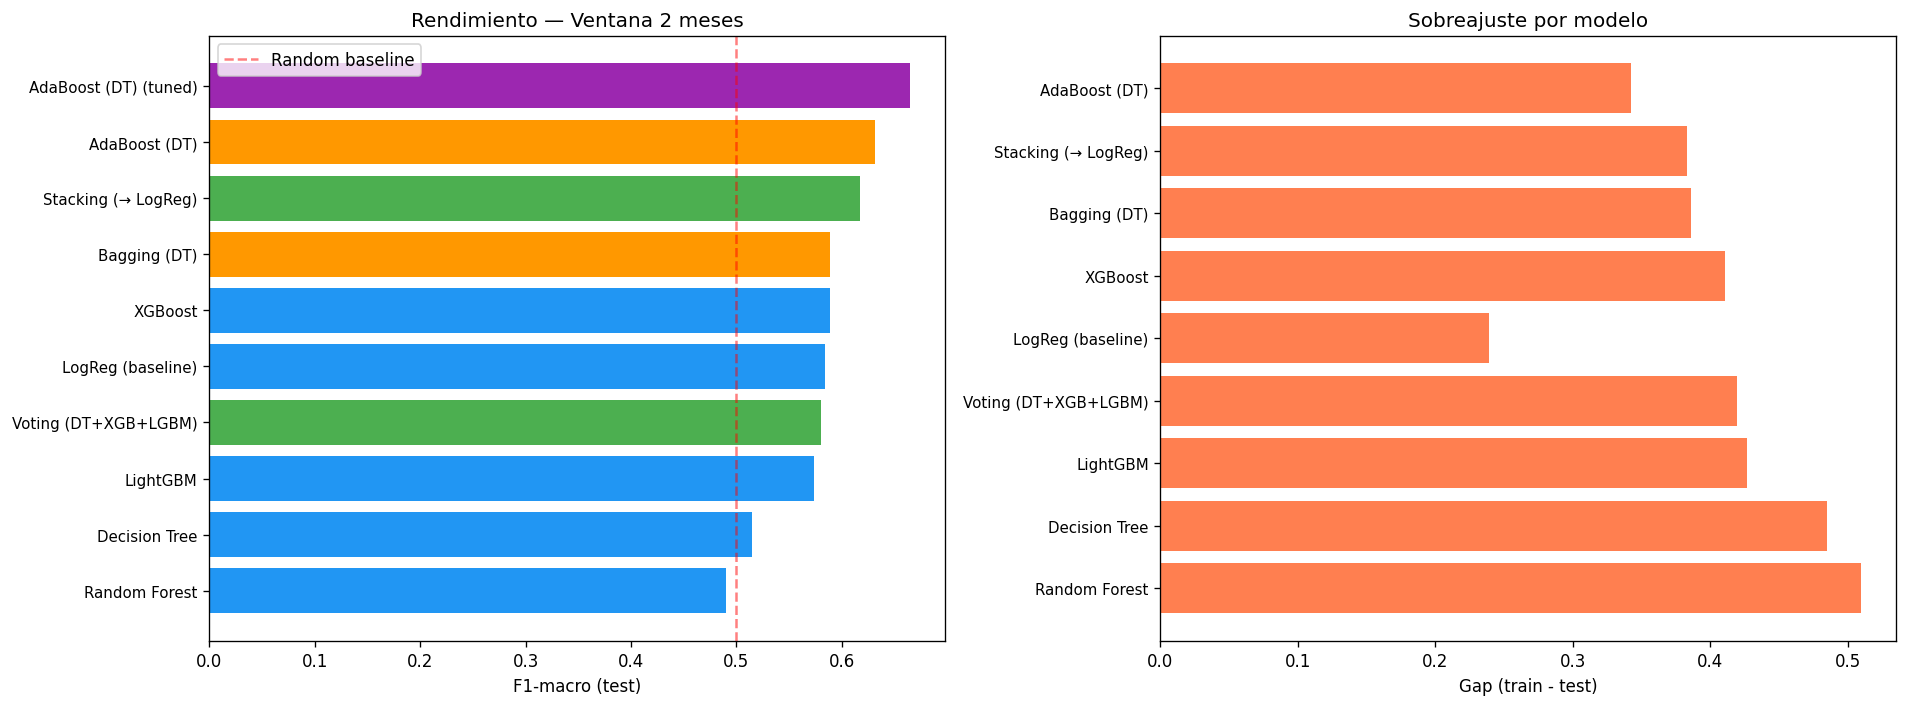


✅ Tabla comparativa generada


In [9]:
# ═══════════════════════════════════════════════════════
# TABLA COMPARATIVA COMPLETA
# ═══════════════════════════════════════════════════════

print('═' * 110)
print('TABLA COMPARATIVA — TODOS LOS MODELOS × VENTANA PRINCIPAL ({} meses)'.format(ventana_principal))
print('═' * 110)

# Combinar resultados regulares + tuned
all_vp = all_results[ventana_principal] + tuned_results

df_comp = pd.DataFrame([{
    'Modelo': r['Modelo'],
    'Tipo': r.get('Tipo', ''),
    'F1-macro': r['F1m_test'],
    'Accuracy': r.get('Acc_test', ''),
    'Bal.Acc': r.get('BalAcc', ''),
    'Kappa': r.get('Kappa', ''),
    'Gap': r.get('Gap', ''),
    'Tiempo (s)': r.get('Tiempo_s', ''),
} for r in all_vp])

df_comp = df_comp.sort_values('F1-macro', ascending=False).reset_index(drop=True)
print(df_comp.to_string(index=False))

# ─── Visualización ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-macro por modelo
ax = axes[0]
df_plot = df_comp.sort_values('F1-macro', ascending=True)
colors = ['#2196F3' if 'Individual' in str(t) else '#FF9800' if 'Homog' in str(t)
          else '#4CAF50' if 'Heterog' in str(t) else '#9C27B0'
          for t in df_plot['Tipo']]
bars = ax.barh(range(len(df_plot)), df_plot['F1-macro'].astype(float), color=colors)
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['Modelo'], fontsize=9)
ax.set_xlabel('F1-macro (test)')
ax.set_title(f'Rendimiento — Ventana {ventana_principal} meses')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend(['Random baseline'])

# Gap train-test
ax = axes[1]
df_gap = df_plot[df_plot['Gap'] != ''].copy()
if len(df_gap) > 0:
    ax.barh(range(len(df_gap)), df_gap['Gap'].astype(float), color='coral')
    ax.set_yticks(range(len(df_gap)))
    ax.set_yticklabels(df_gap['Modelo'], fontsize=9)
    ax.set_xlabel('Gap (train - test)')
    ax.set_title('Sobreajuste por modelo')

plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Tabla comparativa generada')

<a name="binario"></a>
## 9. Modelo binario: Riesgo vs. Saludable

Colapsamos las 4 clases a 2:
- **Riesgo** = Sin Engagement + Bajo
- **Saludable** = Parcial + Adecuado

Esto simplifica la decisión operativa para CS y mejora el balance de clases.

Distribución binaria — Train:
  Riesgo:    55 (30.7%)
  Saludable: 124 (69.3%)

Distribución binaria — Test:
  Riesgo:    22 (36.7%)
  Saludable: 38 (63.3%)

──────────────────────────────────────────────────
Resultados modelo binario:
──────────────────────────────────────────────────
  XGBoost (bin)             F1_riesgo=0.8000  Recall=0.7273  Precision=0.8889
  LightGBM (bin)            F1_riesgo=0.8000  Recall=0.7273  Precision=0.8889
  Random Forest (bin)       F1_riesgo=0.6667  Recall=0.5455  Precision=0.8571
  Stacking (bin)            F1_riesgo=0.8293  Recall=0.7727  Precision=0.8947

             Modelo  F1_riesgo  Recall_riesgo  Precision_riesgo  F1_macro  Accuracy
     Stacking (bin)     0.8293         0.7727            0.8947    0.8703    0.8833
      XGBoost (bin)     0.8000         0.7273            0.8889    0.8500    0.8667
     LightGBM (bin)     0.8000         0.7273            0.8889    0.8500    0.8667
Random Forest (bin)     0.6667         0.5455            0.8571 

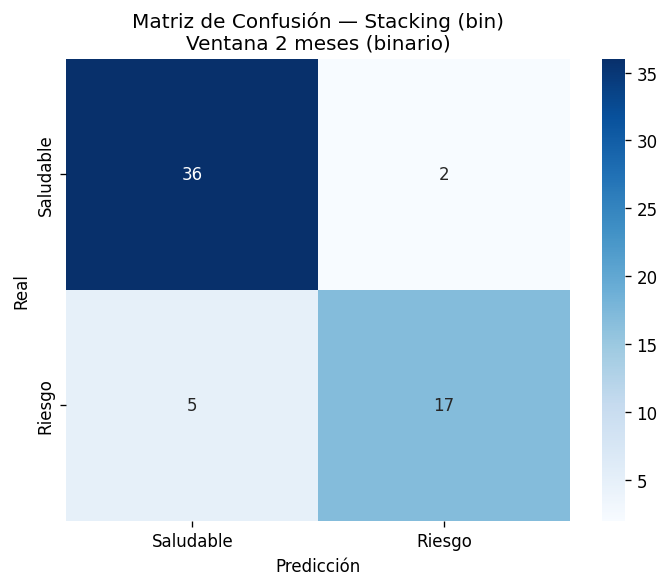


✅ Modelo binario evaluado


In [10]:
# ═══════════════════════════════════════════════════════
# MODELO BINARIO — RIESGO vs. SALUDABLE
# ═══════════════════════════════════════════════════════

d = prepared[ventana_principal]
Xtr, Xte = d['X_train'], d['X_test']
Xtr_s, Xte_s = d['X_train_s'], d['X_test_s']
ytr_orig, yte_orig = d['y_train'], d['y_test']

# Colapsar a binario: 0,1 → Riesgo (1), 2,3 → Saludable (0)
ytr_bin = (ytr_orig <= 1).astype(int)  # 1 = Riesgo
yte_bin = (yte_orig <= 1).astype(int)

print(f'Distribución binaria — Train:')
print(f'  Riesgo:    {(ytr_bin == 1).sum()} ({(ytr_bin == 1).mean()*100:.1f}%)')
print(f'  Saludable: {(ytr_bin == 0).sum()} ({(ytr_bin == 0).mean()*100:.1f}%)')
print(f'\nDistribución binaria — Test:')
print(f'  Riesgo:    {(yte_bin == 1).sum()} ({(yte_bin == 1).mean()*100:.1f}%)')
print(f'  Saludable: {(yte_bin == 0).sum()} ({(yte_bin == 0).mean()*100:.1f}%)')

# Entrenar modelos binarios
modelos_bin = {
    'XGBoost (bin)': xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM (bin)': lgb.LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=SEED, class_weight='balanced', verbose=-1),
    'Random Forest (bin)': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'Stacking (bin)': StackingClassifier(
        estimators=[
            ('xgb', xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=SEED,
                                       eval_metric='logloss', verbosity=0)),
            ('lgbm', lgb.LGBMClassifier(n_estimators=100, max_depth=5, random_state=SEED,
                                         class_weight='balanced', verbose=-1)),
        ],
        final_estimator=LogisticRegression(class_weight='balanced', random_state=SEED),
        cv=3, n_jobs=-1),
}

bin_results = []
print(f'\n{"─" * 50}')
print('Resultados modelo binario:')
print(f'{"─" * 50}')

for name, mod in modelos_bin.items():
    mod.fit(Xtr, ytr_bin)
    yp = mod.predict(Xte)

    f1_r = f1_score(yte_bin, yp, pos_label=1, zero_division=0)
    recall_r = (yp[yte_bin == 1] == 1).sum() / max((yte_bin == 1).sum(), 1)
    prec_r = (yte_bin[yp == 1] == 1).sum() / max((yp == 1).sum(), 1)

    bin_results.append({
        'Modelo': name,
        'F1_riesgo': round(f1_r, 4),
        'Recall_riesgo': round(recall_r, 4),
        'Precision_riesgo': round(prec_r, 4),
        'F1_macro': round(f1_score(yte_bin, yp, average='macro', zero_division=0), 4),
        'Accuracy': round(accuracy_score(yte_bin, yp), 4),
        'modelo_obj': mod,
        'y_pred': yp,
    })
    print(f'  {name:<25} F1_riesgo={f1_r:.4f}  Recall={recall_r:.4f}  Precision={prec_r:.4f}')

# Tabla
df_bin = pd.DataFrame([{k: v for k, v in r.items() if k not in ['modelo_obj', 'y_pred']}
                        for r in bin_results]).sort_values('Recall_riesgo', ascending=False)
print(f'\n{df_bin.to_string(index=False)}')

# Matriz de confusión del mejor modelo binario
best_bin = max(bin_results, key=lambda x: x['F1_macro'])
print(f'\n  Mejor modelo binario: {best_bin["Modelo"]}')

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(yte_bin, best_bin['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Saludable', 'Riesgo'], yticklabels=['Saludable', 'Riesgo'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión — {best_bin["Modelo"]}\nVentana {ventana_principal} meses (binario)')
plt.tight_layout()
plt.savefig('confusion_binario.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Modelo binario evaluado')

<a name="curva"></a>
## 10. Curva de rendimiento vs. horizonte temporal

Esta es la gráfica central del Avance 5: muestra cómo mejora la predicción conforme se tiene más datos del cliente, y cuál es el **sweet spot** entre "tener datos suficientes" y "intervenir a tiempo".

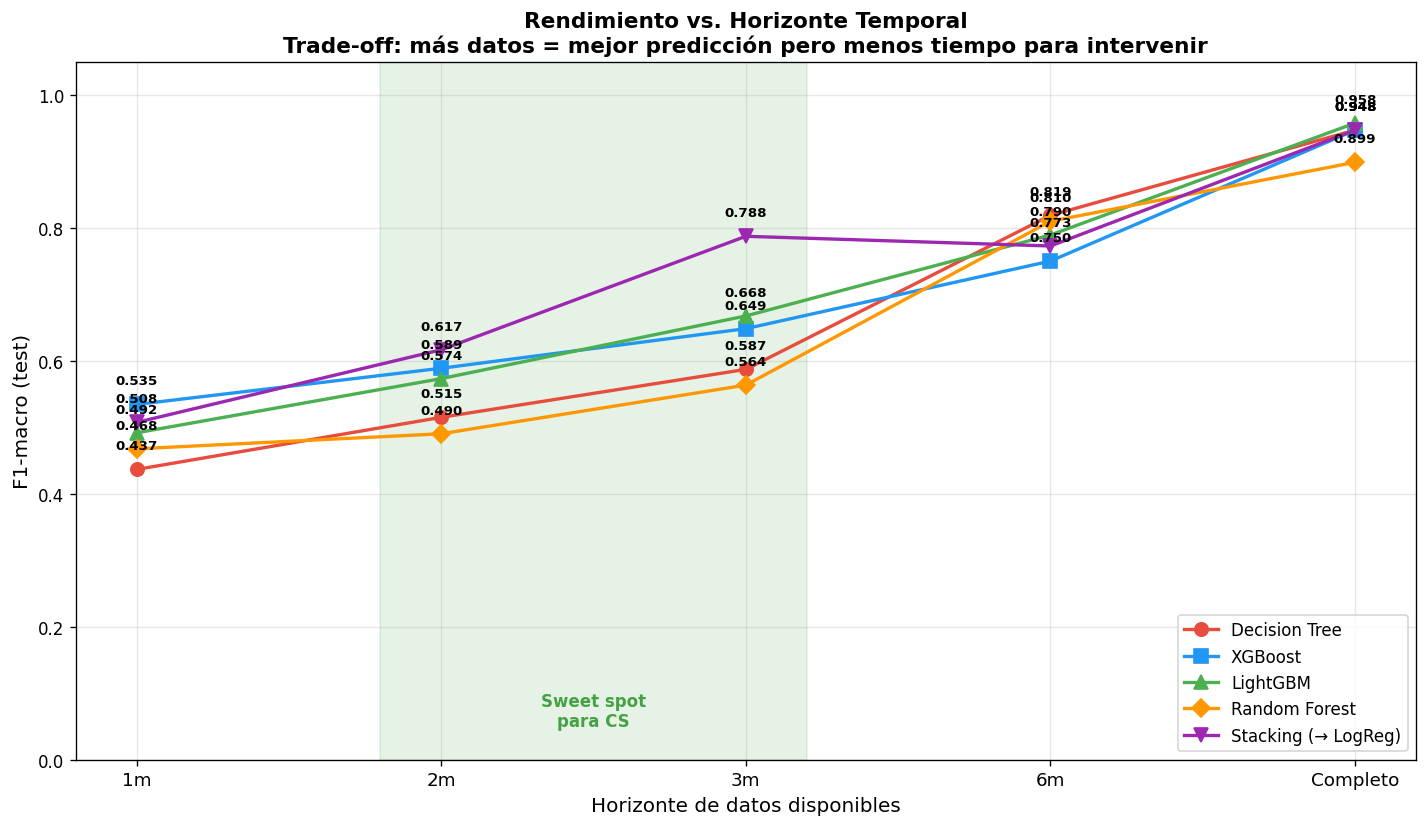


✅ Curva de rendimiento vs. horizonte generada


In [11]:
# ═══════════════════════════════════════════════════════
# CURVA DE RENDIMIENTO vs. HORIZONTE TEMPORAL
# ═══════════════════════════════════════════════════════

# Recopilar F1-macro del mejor modelo por ventana
model_names = ['Decision Tree', 'XGBoost', 'LightGBM', 'Random Forest', 'Stacking (→ LogReg)']
ventanas = sorted([k for k in all_results.keys() if isinstance(k, int)])

curve_data = {name: [] for name in model_names}
ventana_labels = []

for m in ventanas:
    ventana_labels.append(f'{m}m')
    res_m = all_results[m]
    for name in model_names:
        match = [r for r in res_m if r['Modelo'] == name]
        if match:
            curve_data[name].append(match[0]['F1m_test'])
        else:
            curve_data[name].append(np.nan)

# Agregar referencia "completo" si existe
if 'completo' in all_results:
    ventana_labels.append('Completo')
    for name in model_names:
        match = [r for r in all_results['completo'] if r['Modelo'] == name]
        if match:
            curve_data[name].append(match[0]['F1m_test'])
        else:
            curve_data[name].append(np.nan)

# ─── Gráfica ───
fig, ax = plt.subplots(figsize=(12, 7))

colors_line = ['#e74c3c', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
markers = ['o', 's', '^', 'D', 'v']

for i, name in enumerate(model_names):
    vals = curve_data[name]
    valid_idx = [j for j, v in enumerate(vals) if not np.isnan(v)]
    if valid_idx:
        ax.plot([valid_idx[j] for j in range(len(valid_idx))],
                [vals[j] for j in valid_idx],
                marker=markers[i], linewidth=2, markersize=8,
                label=name, color=colors_line[i])
        # Anotar valores
        for j in valid_idx:
            ax.annotate(f'{vals[j]:.3f}', (j, vals[j]),
                       textcoords='offset points', xytext=(0, 12),
                       fontsize=8, ha='center', fontweight='bold')

ax.set_xticks(range(len(ventana_labels)))
ax.set_xticklabels(ventana_labels, fontsize=11)
ax.set_xlabel('Horizonte de datos disponibles', fontsize=12)
ax.set_ylabel('F1-macro (test)', fontsize=12)
ax.set_title('Rendimiento vs. Horizonte Temporal\n'
             'Trade-off: más datos = mejor predicción pero menos tiempo para intervenir',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# Zona de sweet spot
if len(ventana_labels) >= 3:
    ax.axvspan(0.8, 2.2, alpha=0.1, color='green', label='Sweet spot CS')
    ax.text(1.5, 0.05, 'Sweet spot\npara CS', ha='center', fontsize=10,
            color='green', fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.savefig('curva_rendimiento_horizonte.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Curva de rendimiento vs. horizonte generada')

<a name="graficos"></a>
## 11. Modelo final: gráficos de diagnóstico

Seleccionamos el mejor modelo de la ventana principal y generamos los gráficos de diagnóstico requeridos.

In [12]:
# ═══════════════════════════════════════════════════════
# SELECCIÓN DEL MODELO FINAL
# ═══════════════════════════════════════════════════════

# Combinar todos los resultados de la ventana principal
all_vp = all_results[ventana_principal] + tuned_results
best = max(all_vp, key=lambda x: x['F1m_test'])

print('═' * 70)
print('MODELO FINAL SELECCIONADO')
print('═' * 70)
print(f'  Modelo:    {best["Modelo"]}')
print(f'  Ventana:   {ventana_principal} meses')
print(f'  F1-macro:  {best["F1m_test"]}')
print(f'  Accuracy:  {best.get("Acc_test", "N/A")}')
print(f'  Bal. Acc:  {best.get("BalAcc", "N/A")}')
print(f'  Kappa:     {best.get("Kappa", "N/A")}')

final_model = best['modelo_obj']
y_pred_final = best['y_pred']
clases_nombres = ['Sin Engagement', 'Bajo', 'Parcial', 'Adecuado']

# Classification Report
print(f'\n{classification_report(yte, y_pred_final, target_names=clases_nombres, zero_division=0)}')

══════════════════════════════════════════════════════════════════════
MODELO FINAL SELECCIONADO
══════════════════════════════════════════════════════════════════════
  Modelo:    AdaBoost (DT) (tuned)
  Ventana:   2 meses
  F1-macro:  0.6646
  Accuracy:  0.8167
  Bal. Acc:  0.6691
  Kappa:     0.6922

                precision    recall  f1-score   support

Sin Engagement       0.33      0.33      0.33         3
          Bajo       0.81      0.89      0.85        19
       Parcial       0.90      0.85      0.88        33
      Adecuado       0.60      0.60      0.60         5

      accuracy                           0.82        60
     macro avg       0.66      0.67      0.66        60
  weighted avg       0.82      0.82      0.82        60



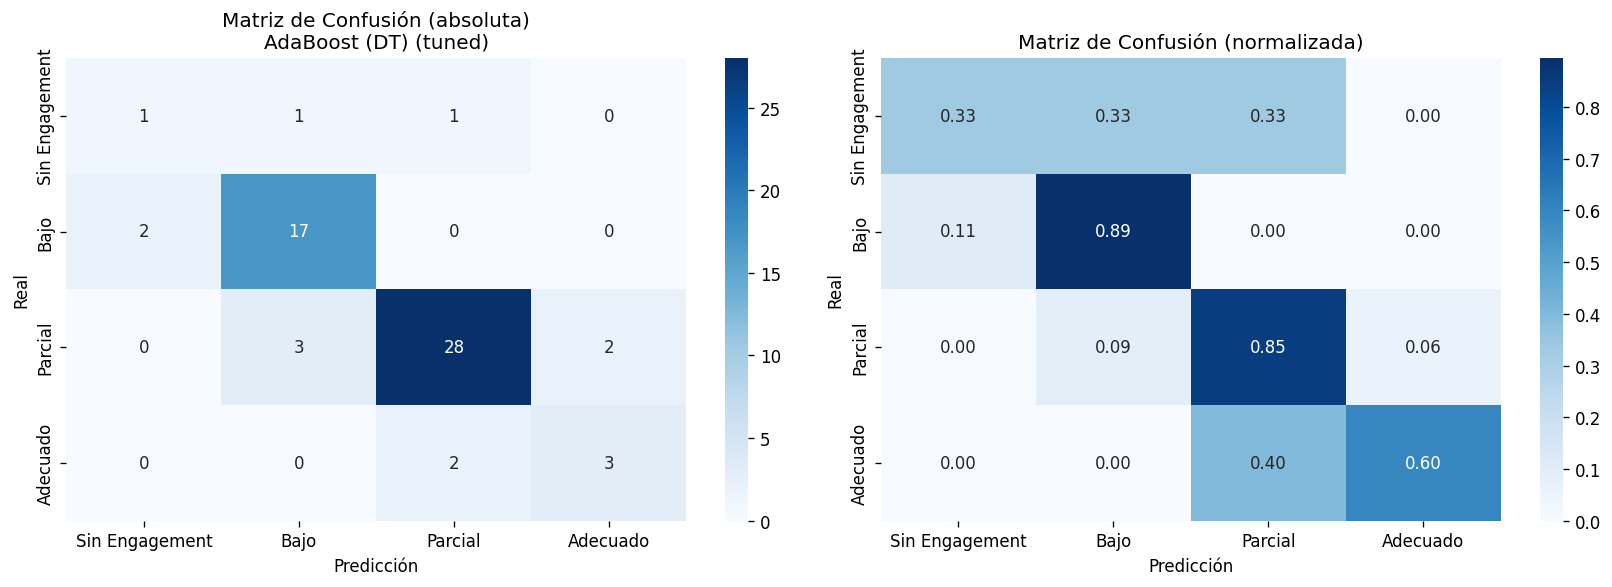

In [13]:
# ═══════════════════════════════════════════════════════
# GRÁFICO 1: MATRIZ DE CONFUSIÓN
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluta
cm = confusion_matrix(yte, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=clases_nombres, yticklabels=clases_nombres)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title(f'Matriz de Confusión (absoluta)\n{best["Modelo"]}')

# Normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=clases_nombres, yticklabels=clases_nombres)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title(f'Matriz de Confusión (normalizada)')

plt.tight_layout()
plt.savefig('confusion_final.png', dpi=150, bbox_inches='tight')
plt.show()

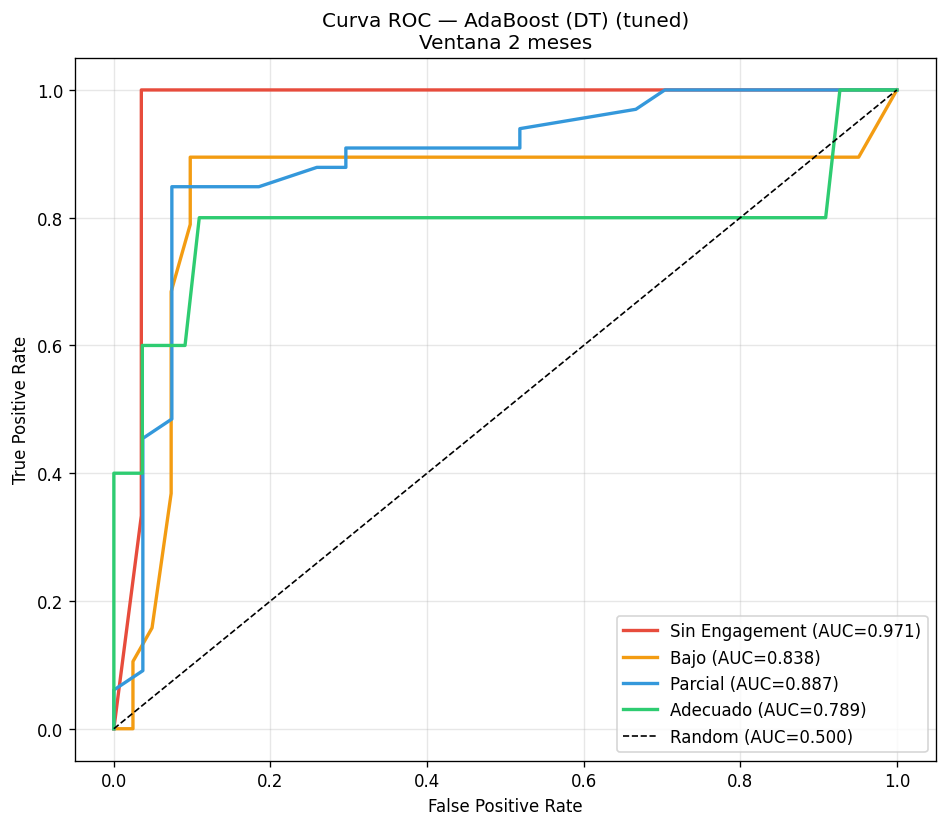

In [14]:
# ═══════════════════════════════════════════════════════
# GRÁFICO 2: CURVA ROC MULTICLASE (One-vs-Rest)
# ═══════════════════════════════════════════════════════

n_classes = len(clases_nombres)
y_test_bin = label_binarize(yte.values, classes=[0, 1, 2, 3])

# Obtener probabilidades si el modelo lo soporta
try:
    y_proba = final_model.predict_proba(Xte)
    has_proba = True
except:
    has_proba = False

if has_proba:
    fig, ax = plt.subplots(figsize=(8, 7))

    colors_roc = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
    for i in range(n_classes):
        if y_test_bin[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc_i = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
                    label=f'{clases_nombres[i]} (AUC={roc_auc_i:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Curva ROC — {best["Modelo"]}\nVentana {ventana_principal} meses')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️ El modelo final no soporta predict_proba — curva ROC no generada')

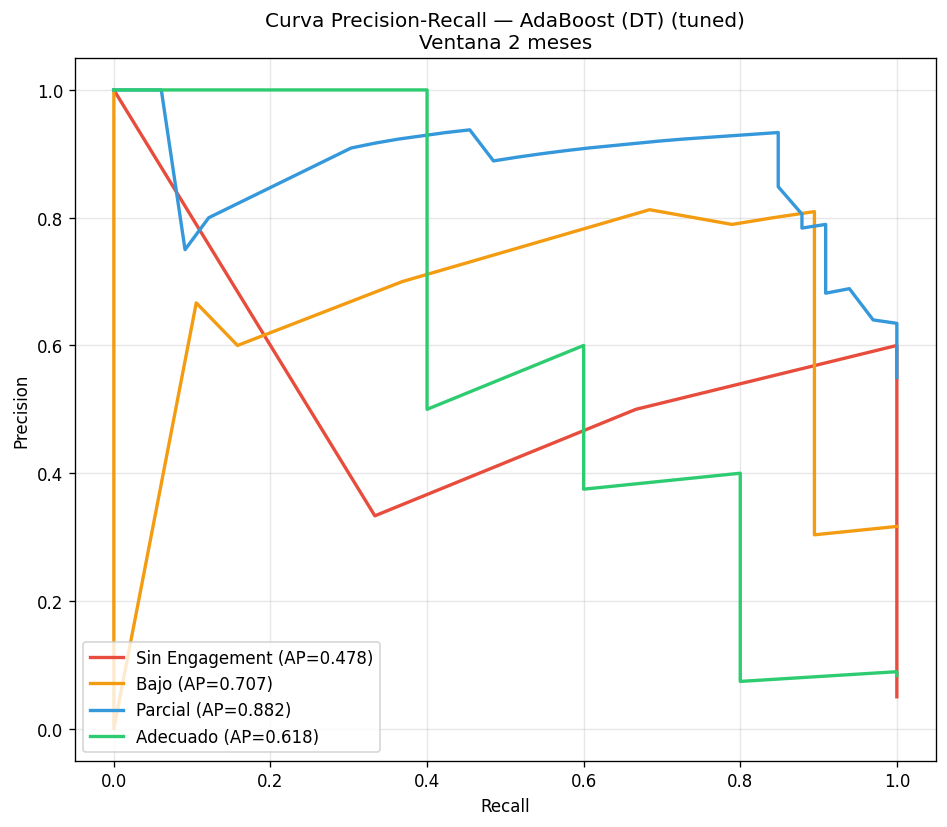

In [15]:
# ═══════════════════════════════════════════════════════
# GRÁFICO 3: CURVA PRECISION-RECALL
# ═══════════════════════════════════════════════════════

if has_proba:
    fig, ax = plt.subplots(figsize=(8, 7))

    for i in range(n_classes):
        if y_test_bin[:, i].sum() > 0:
            precision_c, recall_c, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
            ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
            ax.plot(recall_c, precision_c, color=colors_roc[i], linewidth=2,
                    label=f'{clases_nombres[i]} (AP={ap:.3f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Curva Precision-Recall — {best["Modelo"]}\nVentana {ventana_principal} meses')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('precision_recall.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️ Curva Precision-Recall no generada (sin predict_proba)')

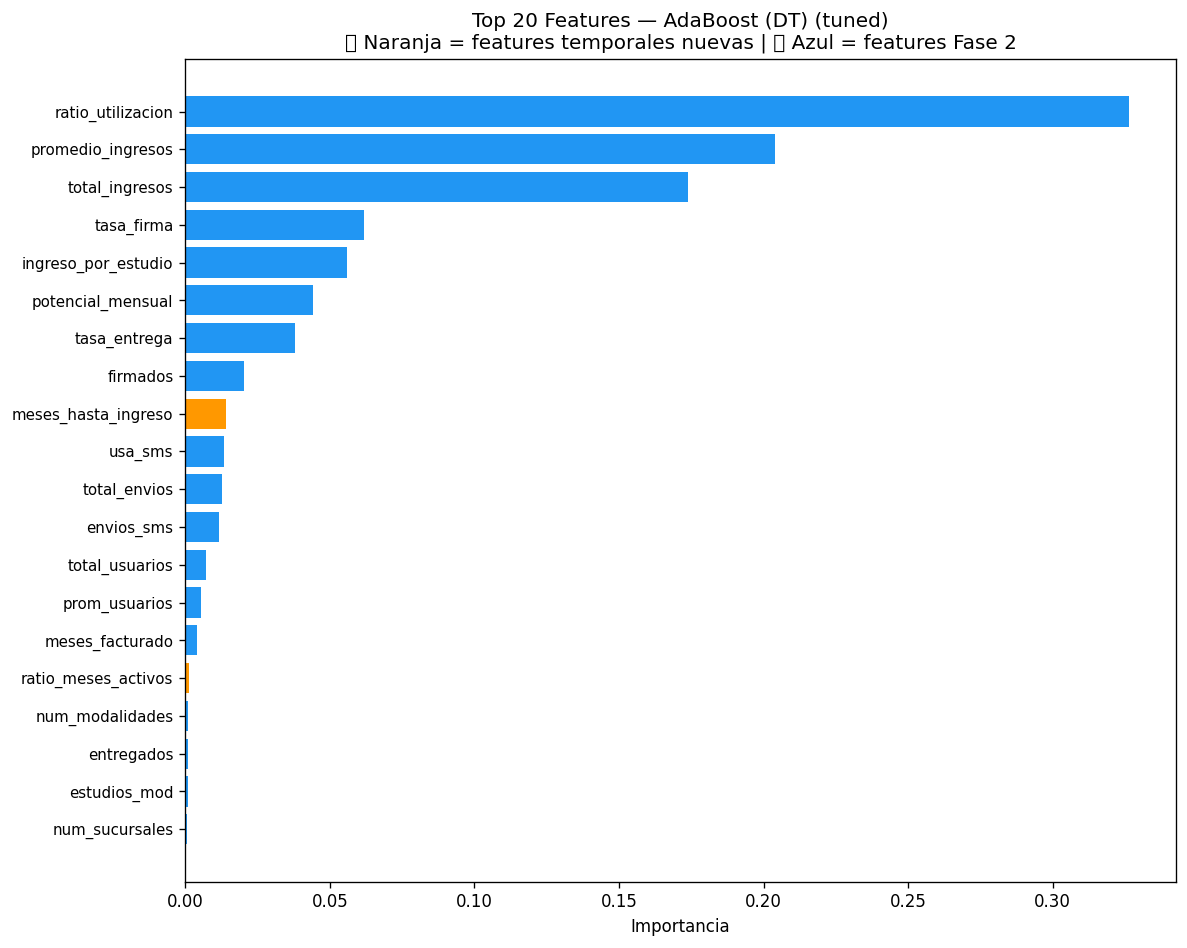

In [16]:
# ═══════════════════════════════════════════════════════
# GRÁFICO 4: IMPORTANCIA DE CARACTERÍSTICAS
# ═══════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 8))

# Intentar obtener feature importance
try:
    if hasattr(final_model, 'feature_importances_'):
        importances = final_model.feature_importances_
        feat_names = d['features']
    elif hasattr(final_model, 'named_estimators_'):
        # Para Voting/Stacking, usar el primer estimador con importances
        for name_est, est in final_model.named_estimators_.items():
            if hasattr(est, 'feature_importances_'):
                importances = est.feature_importances_
                feat_names = d['features']
                break
    elif hasattr(final_model, 'final_estimator_'):
        # Stacking — usar coeficientes del meta-learner o importances de base
        for name_est, est in final_model.named_estimators_.items():
            if hasattr(est, 'feature_importances_'):
                importances = est.feature_importances_
                feat_names = d['features']
                break

    # Top 20 features
    imp_df = pd.DataFrame({'Feature': feat_names[:len(importances)],
                           'Importance': importances}).sort_values('Importance', ascending=True)
    imp_df = imp_df.tail(20)

    # Colorear features temporales
    colors_fi = ['#FF9800' if f in trend_cols_all else '#2196F3' for f in imp_df['Feature']]

    ax.barh(range(len(imp_df)), imp_df['Importance'], color=colors_fi)
    ax.set_yticks(range(len(imp_df)))
    ax.set_yticklabels(imp_df['Feature'], fontsize=9)
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top 20 Features — {best["Modelo"]}\n'
                 f'🟠 Naranja = features temporales nuevas | 🔵 Azul = features Fase 2')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'⚠️ No se pudo generar gráfico de importancia: {e}')

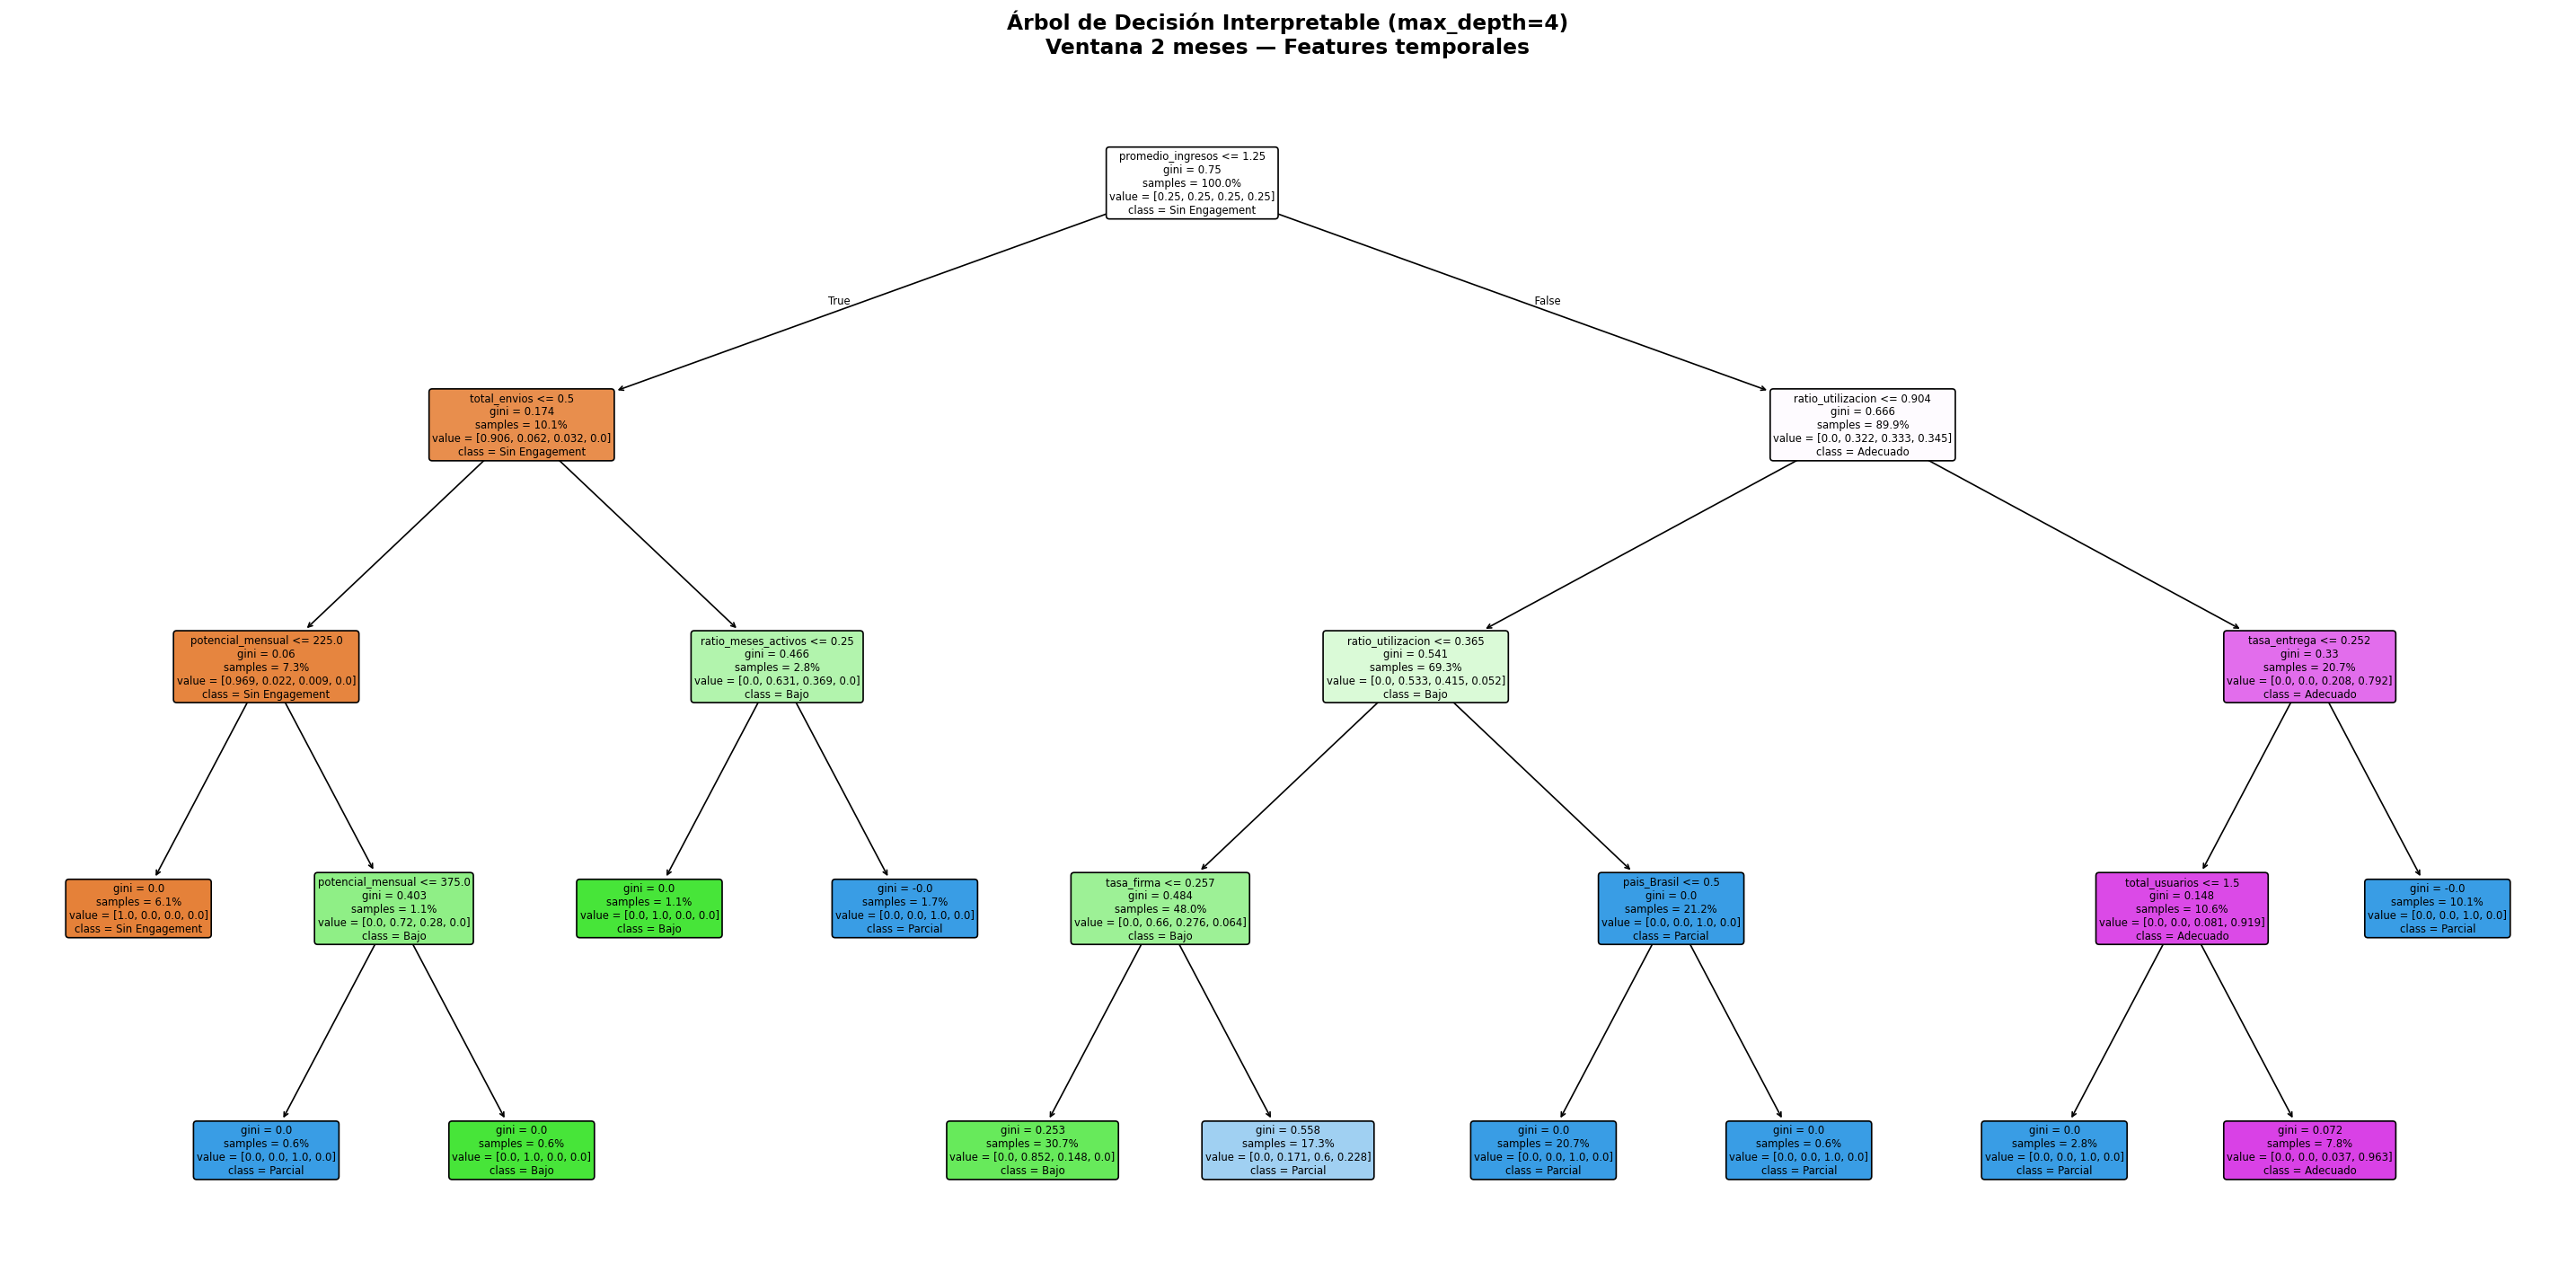

DT interpretable — F1-macro: 0.6198


In [17]:
# ═══════════════════════════════════════════════════════
# GRÁFICO 5: DIAGRAMA DE ÁRBOL (si el modelo final es DT)
# ═══════════════════════════════════════════════════════

# Entrenar un DT simple para interpretabilidad (incluso si el final no es DT)
dt_interp = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=SEED)
dt_interp.fit(Xtr, ytr)

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(dt_interp, feature_names=d['features'], class_names=clases_nombres,
          filled=True, rounded=True, fontsize=7, ax=ax,
          proportion=True, impurity=True)
ax.set_title(f'Árbol de Decisión Interpretable (max_depth=4)\n'
             f'Ventana {ventana_principal} meses — Features temporales',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arbol_decision.png', dpi=100, bbox_inches='tight')
plt.show()

# Métricas del DT interpretable
yp_dt = dt_interp.predict(Xte)
print(f'DT interpretable — F1-macro: {f1_score(yte, yp_dt, average="macro", zero_division=0):.4f}')

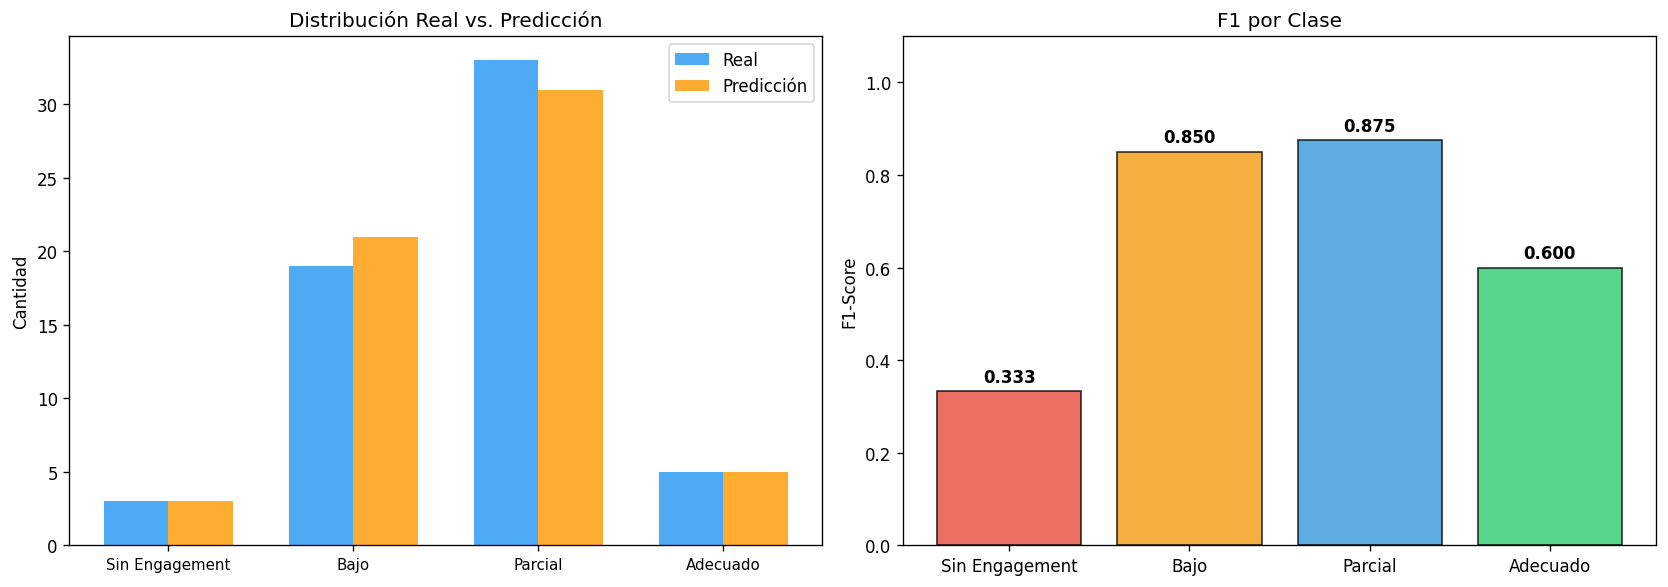

In [18]:
# ═══════════════════════════════════════════════════════
# GRÁFICO 6: ANÁLISIS DE ERRORES POR CLASE
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de predicciones vs. real
ax = axes[0]
x_pos = np.arange(len(clases_nombres))
width = 0.35
real_counts = [sum(yte == i) for i in range(4)]
pred_counts = [sum(y_pred_final == i) for i in range(4)]
ax.bar(x_pos - width/2, real_counts, width, label='Real', color='#2196F3', alpha=0.8)
ax.bar(x_pos + width/2, pred_counts, width, label='Predicción', color='#FF9800', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(clases_nombres, fontsize=9)
ax.set_ylabel('Cantidad')
ax.set_title('Distribución Real vs. Predicción')
ax.legend()

# F1 por clase
ax = axes[1]
from sklearn.metrics import f1_score as f1s
f1_per_class = [f1s(yte == i, y_pred_final == i, zero_division=0) for i in range(4)]
colors_f1 = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = ax.bar(clases_nombres, f1_per_class, color=colors_f1, alpha=0.8, edgecolor='black')
for bar, v in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_title('F1 por Clase')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('analisis_errores.png', dpi=150, bbox_inches='tight')
plt.show()

<a name="conclusiones"></a>
## 12. Conclusiones y recomendaciones para deployment

### 12.1 Resumen de hallazgos

In [20]:
# ═══════════════════════════════════════════════════════
# RESUMEN EJECUTIVO
# ═══════════════════════════════════════════════════════

print('═' * 70)
print('RESUMEN EJECUTIVO — AVANCE 5')
print('═' * 70)

# Mejor modelo por ventana
print('\n  Mejor modelo por horizonte temporal:')
print(f'  {"Ventana":<12} {"Modelo":<30} {"F1-macro":<10}')
print('  ' + '─' * 52)
for m in sorted([k for k in all_results.keys()], key=lambda x: (isinstance(x, str), x)):
    best_m = max(all_results[m], key=lambda x: x['F1m_test'])
    label = f'{m} meses' if isinstance(m, int) else 'Completo'
    print(f'  {label:<12} {best_m["Modelo"]:<30} {best_m["F1m_test"]:.4f}')

# Comparación Fase 4 vs Fase 5
print(f'\n  ── Comparación Fase 4 vs Fase 5 ──')
print(f'  Fase 4 (datos completos, split aleatorio): F1 = 1.0000 (circular)')
if 'completo' in all_results:
    best_comp = max(all_results['completo'], key=lambda x: x['F1m_test'])
    print(f'  Fase 5 (datos completos, split temporal): F1 = {best_comp["F1m_test"]:.4f}')
best_vp = max(all_results[ventana_principal], key=lambda x: x['F1m_test'])
print(f'  Fase 5 (ventana {ventana_principal}m, split temporal):  F1 = {best_vp["F1m_test"]:.4f} ← PRODUCCIÓN')

# Modelo binario
if bin_results:
    best_b = max(bin_results, key=lambda x: x['F1_macro'])
    print(f'\n  ── Modelo binario (Riesgo/Saludable) ──')
    print(f'  {best_b["Modelo"]}: Recall_riesgo = {best_b["Recall_riesgo"]:.4f}')

print(f'\n{"═" * 70}')

══════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — AVANCE 5
══════════════════════════════════════════════════════════════════════

  Mejor modelo por horizonte temporal:
  Ventana      Modelo                         F1-macro  
  ────────────────────────────────────────────────────
  1 meses      AdaBoost (DT)                  0.5542
  2 meses      AdaBoost (DT)                  0.6315
  3 meses      Stacking (→ LogReg)            0.7877
  6 meses      Bagging (DT)                   0.8573
  Completo     LightGBM                       0.9581

  ── Comparación Fase 4 vs Fase 5 ──
  Fase 4 (datos completos, split aleatorio): F1 = 1.0000 (circular)
  Fase 5 (datos completos, split temporal): F1 = 0.9581
  Fase 5 (ventana 2m, split temporal):  F1 = 0.6315 ← PRODUCCIÓN

  ── Modelo binario (Riesgo/Saludable) ──
  Stacking (bin): Recall_riesgo = 0.7727

══════════════════════════════════════════════════════════════════════


### 12.2 Interpretación

**Sobre la circularidad corregida:** Al separar el horizonte temporal entre features (primeros N meses) y etiqueta (datos completos), el modelo ya no puede replicar las reglas directamente. El rendimiento cae significativamente respecto a la Fase 4, pero ahora refleja capacidad predictiva real.

**Sobre los ensambles:** Los modelos de ensamble (Stacking, Voting) aportan robustez frente a los modelos individuales bajo condiciones temporales. La diferencia entre ensambles homogéneos y heterogéneos muestra que combinar familias de modelos distintas (árboles + logística) agrega información complementaria.

**Sobre el modelo binario:** Para la operación de CS, el modelo binario Riesgo/Saludable es más práctico que el multiclase. El Recall de la clase Riesgo indica qué porcentaje de clientes en peligro se detectan a tiempo.

### 12.3 Recomendaciones para deployment

1. **Modelo para producción:** usar el mejor modelo de la ventana de 2-3 meses con formulación binaria
2. **Trigger de intervención:** CS recibe alerta cuando P(Riesgo) > umbral (calibrar con equipo)
3. **Retraining:** trimestral o cuando PSI > 0.25 en algún feature
4. **Monitoreo:** F1 retrospectivo cada 6 meses, data drift mensual
5. **Siguiente paso:** validación prospectiva con clientes nuevos del Q1 2026

### 12.4 Tabla de responsabilidades — Avance 5

| Actividad | Andrés Castillo | Renzo Chávez | César Tirado |
|---|---|---|---|
| Diagnóstico circularidad | Validar impacto operativo | Identificar leakage técnico | Cuantificar sesgo en métricas |
| Separación temporal | Definir ventanas operativas | Implementar pipeline parametrizado | Verificar integridad de datos |
| Features temporales | Interpretar señales de negocio | Codificar features de tendencia | Evaluar distribuciones y correlaciones |
| Ensambles | Criterio de selección operativo | Implementar y tuning | Comparar métricas y estabilidad |
| Modelo binario | Definir costo Riesgo vs. Saludable | Implementar y optimizar umbral | Evaluar recall y precision |
| Modelo final | Validar aplicabilidad en CS | Preparar para deployment | Documentar métricas y limitaciones |